In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from typing import Optional, List, Union
import gc
import numpy as np
from scipy.ndimage import gaussian_filter
import deepwave

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors
plt.rcParams['font.family'] = ['Times New Roman', 'DejaVu Serif', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['font.size'] = 14
from tqdm import tqdm
import math
import time
import tomli
import random

import os
import shutil
import sys

from example_to_dyy.funcs import draw_kernels

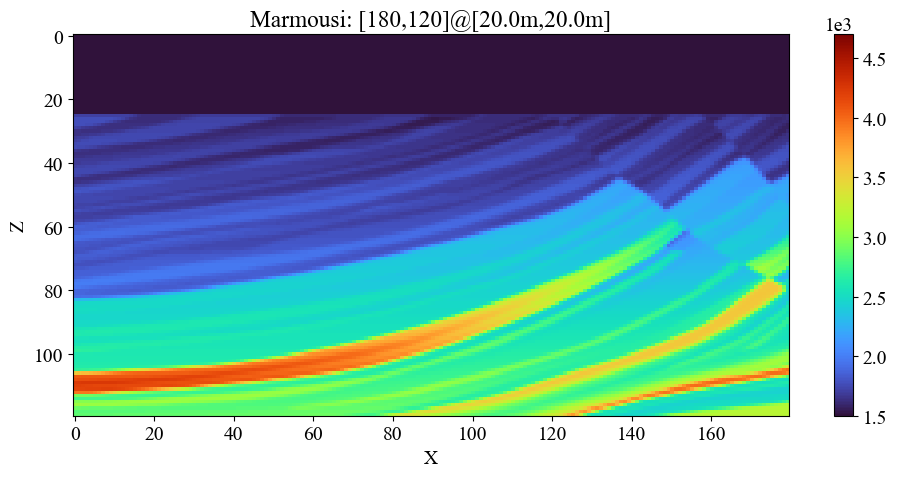

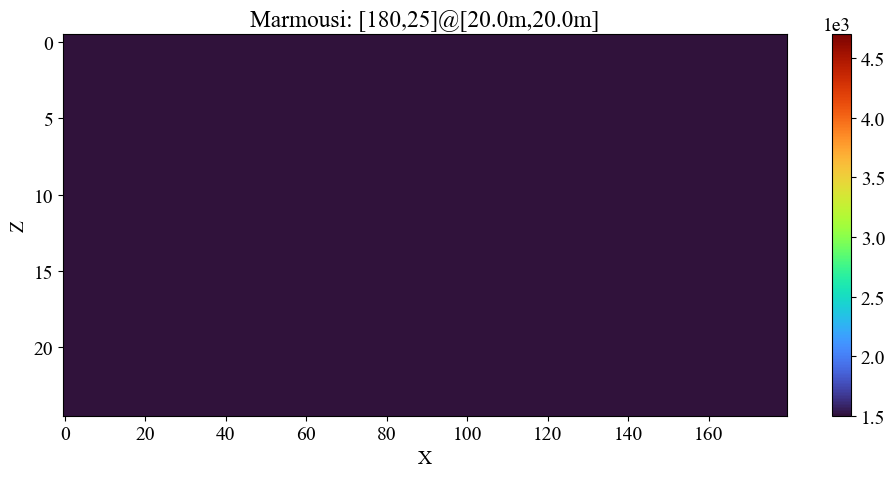

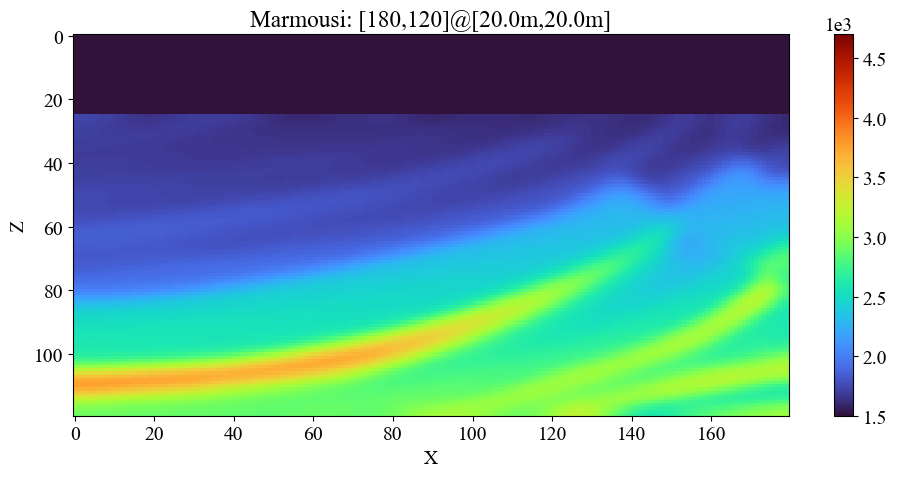

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dtype = torch.float32
cm_v = 'turbo'
cm_r = 'gray'

### 2D model: Marmousi
### unit: m, s, kg/m^3
figsize = (10, 5)

nx, nz = 541, 176
dx, dz = 20.0, 20.0
wl = 25 ## 水层

v_true = torch.from_file('example_to_dyy/models/v_true_zm25.dat', size=nx*nz, dtype=dtype).reshape(nx, nz).to(device)
max_vel, min_vel = v_true.max().item(), 1500.0
norm_v = colors.Normalize(vmax=max_vel, vmin=min_vel)

clip_nx, start_x=180, 120
clip_nz= 120
v_true = v_true[start_x:clip_nx+start_x, 0:clip_nz]
draw_kernels.draw_snap(v_true, figsize=figsize, cmap=cm_v, norm=norm_v, title=f"Marmousi: [{clip_nx},{clip_nz}]@[{dx}m,{dz}m]")

fix_upper_layer = v_true[:, :wl]
draw_kernels.draw_snap(fix_upper_layer, figsize=figsize, cmap=cm_v, norm=norm_v, title=f"Marmousi: [{clip_nx},{wl}]@[{dx}m,{dz}m]")

## Smoothed model: gaussian smooth with sigma=6
sigma = 3
v_smth = torch.cat((v_true[:,:wl], torch.tensor(gaussian_filter(v_true[:,wl:].cpu().numpy(), sigma=sigma), dtype=dtype).to(device)), dim=1)
draw_kernels.draw_snap(v_smth, figsize=figsize, cmap=cm_v, norm=norm_v, title=f"Marmousi: [{clip_nx},{clip_nz}]@[{dx}m,{dz}m]")
